In [2]:
import glob
from astropy.io import fits

fits_files = glob.glob('data/*.fits')
hdul = fits.open(fits_files[1])

In [3]:
hdul[1].data

FITS_rec([([3781.75, 3781.76, 3781.77, ..., 6913.57, 6913.58, 6913.59], [  328.03732 ,   149.94778 ,   388.7066  , ...,  7320.707   ,  6347.75    ,  5253.9106  ], [nan, nan, nan, ..., nan, nan, nan])],
         dtype=(numpy.record, [('WAVE', '>f8', (313185,)), ('FLUX', '>f4', (313185,)), ('ERR', '>f4', (313185,))]))

In [4]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [6]:
len(hdul[1].data['FLUX'][0])

313185

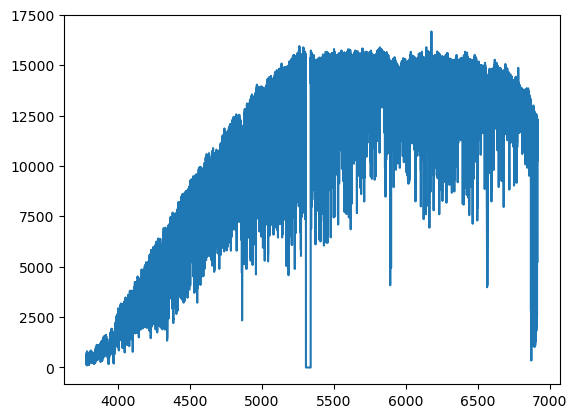

In [7]:
plt.plot(hdul[1].data['WAVE'][0], hdul[1].data['FLUX'][0])

In [22]:
hdul[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
DATASUM = '0       '           / data unit checksum updated 2014-10-06T14:38:00 
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H   
DATE    = '2014-09-08T07:32:39.359' / UT date when this file was written        
INSTRUME= 'HARPS   '           / Instrument used.                               
RA      =            48.668425 / 03:14:40.4 RA (J2000) pointing (deg)           
DEC     =            -35.55808 / -35:33:29.0 DEC (J2000) pointing (deg)         
EQUINOX =                2000. / Standard FK5 (years)                           
RADECSYS= 'FK5     '        

In [12]:
import numpy as np
len(hdul[1].data['WAVE'][0][np.isclose(hdul[1].data['FLUX'][0], 0)])

3295

In [28]:
from tqdm import tqdm
wavelengths = []
fluxes = []
errors = []

snrs = []
mjds = []
exptimes = []

for f in tqdm(fits_files):
    try:
        hdul = fits.open(f)
        wvs = hdul[1].data['WAVE'][0]
        flx = hdul[1].data['FLUX'][0]
        err = hdul[1].data['ERR'][0]
        snr = hdul[0].header['SNR']
        mjd = hdul[0].header['MJD-OBS']
        exptime = hdul[0].header['EXPTIME']
    except:
        continue
    wavelengths.append(wvs)
    fluxes.append(flx)
    errors.append(err)
    snrs.append(snr)
    mjds.append(mjd)
    exptimes.append(exptime)

100%|██████████| 22/22 [00:00<00:00, 35.09it/s]


In [32]:
# Find the maximum length
maxlen = max([len(wvs) for wvs in wavelengths])

# Pad all arrays to the same size
wavelengths_padded = np.array([np.pad(wvs, (0, maxlen - len(wvs)), constant_values=np.nan) for wvs in wavelengths])
fluxes_padded = np.array([np.pad(flx, (0, maxlen - len(flx)), constant_values=np.nan) for flx in fluxes])
errors_padded = np.array([np.pad(err, (0, maxlen - len(err)), constant_values=np.nan) for err in errors])

In [43]:
import zarr
import numpy as np
from zarr.codecs import BloscCodec

# Open Zarr v3 group
root = zarr.open_group(
    "harps_data.zarr",
    mode="w",
    zarr_version=3
)

# Zarr v3 native codec (NOT numcodecs.Blosc)
compressor = BloscCodec(cname="zstd", clevel=3)

# Create arrays
root.create_array(
    "wavelengths",
    data=wavelengths_padded,
    compressors=[compressor]
)

root.create_array(
    "fluxes",
    data=fluxes_padded,
    compressors=[compressor]
)

root.create_array(
    "errors",
    data=errors_padded,
    compressors=[compressor]
)

root.create_array("snrs", data=np.asarray(snrs))
root.create_array("mjds", data=np.asarray(mjds))
root.create_array("exptimes", data=np.asarray(exptimes))

print("Saved data to harps_data.zarr (Zarr v3)")

Saved data to harps_data.zarr (Zarr v3)
